# Insurance BI Analytics — Risk, Fraud & Revenue Analysis

This notebook is my EDA on a simulated motor insurance portfolio of 1 million customers.
I built the dataset myself in Python and ran the core analysis in SQL Server first.
This notebook is the visual layer on top of that.

Data covers policy sales in 2024 and claims filed in 2025 and early 2026.


## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12


## Loading the Data

In [2]:
policy = pd.read_csv(r"C:\Users\ASUS\policy_enhanced.csv", parse_dates=[
    'Policy_Purchase_Date', 'Policy_Start_Date', 'Policy_End_Date'
])

claims = pd.read_csv(r"C:\Users\ASUS\claims_enhanced.csv", parse_dates=['Claim_Date'])

print(f"policy  : {policy.shape}")
print(f"claims  : {claims.shape}")


policy  : (1000000, 11)
claims  : (49367, 7)


In [3]:
policy.head()


,Customer_ID,Vehicle_ID,Customer_Age,City_Tier,Vehicle_Category,Vehicle_Value,Policy_Tenure,Premium,Policy_Purchase_Date,Policy_Start_Date,Policy_End_Date
0,1,1,47,3,Sedan,800000,2,2100.0,2024-04-12,2025-04-12,2027-04-12
1,2,2,39,1,SUV,1200000,3,3795.0,2024-12-14,2025-12-14,2028-12-13
2,3,3,36,3,SUV,1200000,2,2200.0,2024-09-27,2025-09-27,2027-09-27
3,4,4,63,1,Hatchback,500000,3,4140.0,2024-04-16,2025-04-16,2028-04-15
4,5,5,42,3,SUV,1200000,2,2200.0,2024-03-12,2025-03-12,2027-03-12


In [4]:
claims.head()


,Claim_ID,Customer_ID,Vehicle_ID,Claim_Amount,Claim_Date,Claim_Type,Is_Fraud_Flag
0,1,18913,18913,49360.41,2025-06-28,1,0
1,2,557443,557443,270027.42,2025-03-28,1,0
2,3,693167,693167,34223.74,2025-10-28,1,0
3,4,766083,766083,34622.56,2025-02-13,1,0
4,5,50739,50739,68787.13,2025-02-13,1,0


In [5]:
# checking dtypes and nulls before anything else
policy.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 11 columns):
 #   Column                Non-Null Count    Dtype         
---  ------                --------------    -----         
 0   Customer_ID           1000000 non-null  int64         
 1   Vehicle_ID            1000000 non-null  int64         
 2   Customer_Age          1000000 non-null  int64         
 3   City_Tier             1000000 non-null  int64         
 4   Vehicle_Category      1000000 non-null  object        
 5   Vehicle_Value         1000000 non-null  int64         
 6   Policy_Tenure         1000000 non-null  int64         
 7   Premium               1000000 non-null  float64       
 8   Policy_Purchase_Date  1000000 non-null  datetime64[ns]
 9   Policy_Start_Date     1000000 non-null  datetime64[ns]
 10  Policy_End_Date       1000000 non-null  datetime64[ns]
dtypes: datetime64[ns](3), float64(1), int64(6), object(1)
memory usage: 83.9+ MB


In [6]:
# no nulls ideally since i simulated this myself
policy.isnull().sum()


Customer_ID             0
Vehicle_ID              0
Customer_Age            0
City_Tier               0
Vehicle_Category        0
Vehicle_Value           0
Policy_Tenure           0
Premium                 0
Policy_Purchase_Date    0
Policy_Start_Date       0
Policy_End_Date         0
dtype: int64

In [7]:
claims.isnull().sum()


Claim_ID         0
Customer_ID      0
Vehicle_ID       0
Claim_Amount     0
Claim_Date       0
Claim_Type       0
Is_Fraud_Flag    0
dtype: int64

In [8]:
# quick stats on key columns
policy[['Customer_Age', 'Vehicle_Value', 'Premium', 'Policy_Tenure']].describe().round(2)


,Customer_Age,Vehicle_Value,Premium,Policy_Tenure
count,1000000.0,1000000.00,1000000.00,1000000.00
mean,44.0,965268.40,2929.31,2.40
std,15.3,577189.27,1187.37,0.92
min,18.0,500000.00,1000.00,1.00
25%,31.0,500000.00,2100.00,2.00
50%,44.0,800000.00,3000.00,2.00
75%,57.0,1200000.00,3780.00,3.00
max,70.0,2500000.00,6900.00,4.00


## Portfolio Summary

In [9]:
# merging on vehicle_id — left join so unclaimed policies stay in
merged = policy.merge(claims, on='Vehicle_ID', how='left')

total_premium     = policy['Premium'].sum()
total_claims      = claims['Claim_Amount'].sum()
loss_ratio        = total_claims / total_premium * 100
fraud_amount      = claims[claims['Is_Fraud_Flag'] == 1]['Claim_Amount'].sum()
fraud_count       = int(claims['Is_Fraud_Flag'].sum())
unclaimed         = policy[~policy['Vehicle_ID'].isin(claims['Vehicle_ID'])].shape[0]
avg_claim         = claims['Claim_Amount'].mean()

print(f"Total Customers      : {len(policy):,}")
print(f"Total Premium        : Rs. {total_premium:,.0f}")
print(f"Total Claims Filed   : {len(claims):,}")
print(f"Total Claim Amount   : Rs. {total_claims:,.0f}")
print(f"Loss Ratio           : {loss_ratio:.2f}%")
print(f"Avg Claim Amount     : Rs. {avg_claim:,.0f}")
print(f"Fraud Claims         : {fraud_count:,}")
print(f"Fraud Amount         : Rs. {fraud_amount:,.0f}")
print(f"Unclaimed Vehicles   : {unclaimed:,}")


Total Customers      : 1,000,000
Total Premium        : Rs. 2,929,306,462
Total Claims Filed   : 49,367
Total Claim Amount   : Rs. 5,497,277,142
Loss Ratio           : 187.66%
Avg Claim Amount     : Rs. 111,355
Fraud Claims         : 967
Fraud Amount         : Rs. 826,560,000
Unclaimed Vehicles   : 951,031


## Claim Amount Distribution

Wanted to check the shape of claim amounts first before going into loss ratios.
Insurance claims are usually right skewed — most are moderate but some are very large.
That's why i used log-normal distribution in the simulation.
Mean being higher than median confirms the skew.


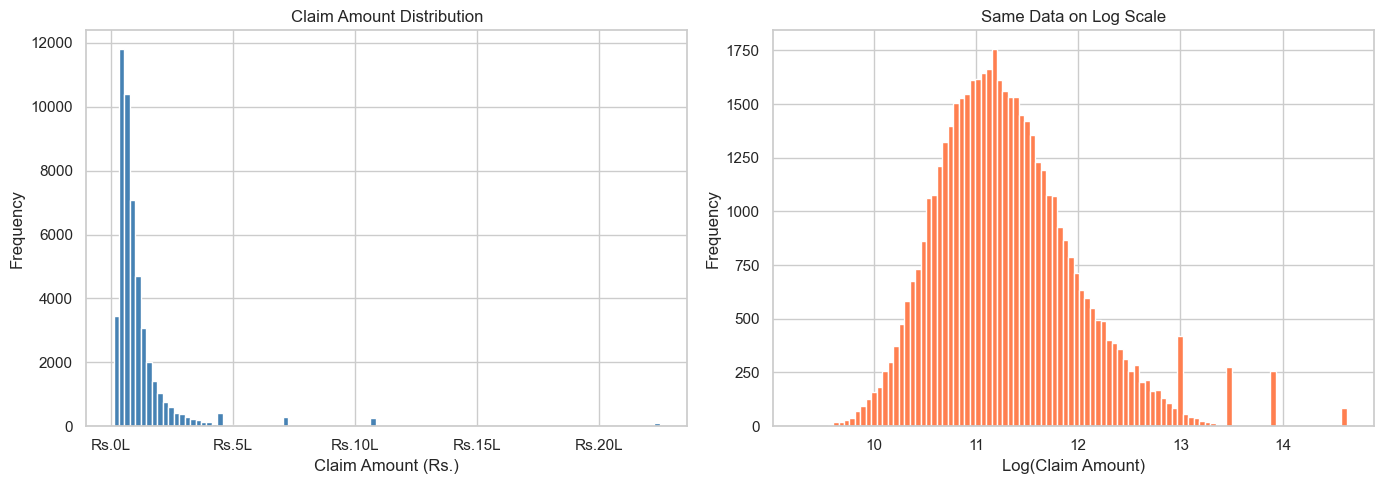

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(claims['Claim_Amount'], bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('Claim Amount Distribution')
axes[0].set_xlabel('Claim Amount (Rs.)')
axes[0].set_ylabel('Frequency')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'Rs.{x/1e5:.0f}L'))

axes[1].hist(np.log(claims['Claim_Amount']), bins=100, color='coral', edgecolor='white')
axes[1].set_title('Same Data on Log Scale')
axes[1].set_xlabel('Log(Claim Amount)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


In [11]:
# mean vs median — mean is higher, confirms right skew
print(f"Mean   : Rs. {claims['Claim_Amount'].mean():,.0f}")
print(f"Median : Rs. {claims['Claim_Amount'].median():,.0f}")


Mean   : Rs. 111,355
Median : Rs. 75,458


## Loss Ratio Analysis

Loss Ratio = Total Claims / Total Premium x 100

Above 100% means we are paying more than we collect.
Checking this across tenure, vehicle category and city tier.


In [12]:
# loss ratio by tenure
tenure_grp = merged.groupby('Policy_Tenure').agg(
    Total_Premium  = ('Premium', 'sum'),
    Total_Claims   = ('Claim_Amount', 'sum'),
    Customers      = ('Customer_ID_x', 'count')
).reset_index().fillna(0)

tenure_grp['Loss_Ratio'] = (tenure_grp['Total_Claims'] / tenure_grp['Total_Premium'] * 100).round(2)

tenure_grp[['Policy_Tenure', 'Customers', 'Loss_Ratio']]


,Policy_Tenure,Customers,Loss_Ratio
0,1,200532,359.98
1,2,300278,181.55
2,3,399492,118.98
3,4,100096,315.29


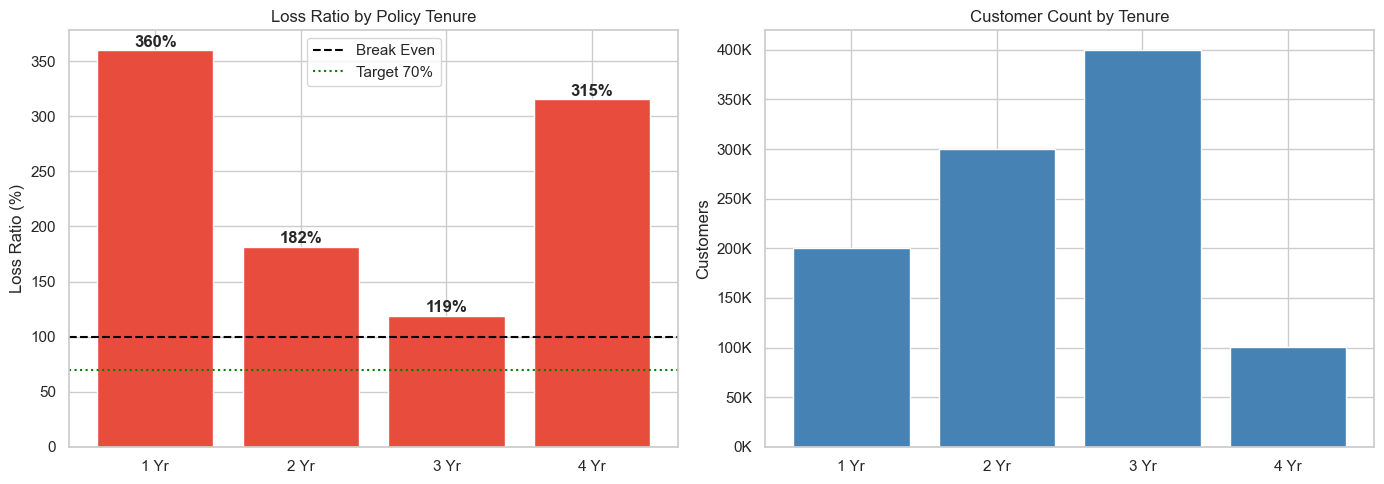

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#e74c3c' if x > 100 else '#2ecc71' for x in tenure_grp['Loss_Ratio']]
bars = axes[0].bar(
    tenure_grp['Policy_Tenure'].astype(str) + ' Yr',
    tenure_grp['Loss_Ratio'],
    color=colors, edgecolor='white'
)
axes[0].axhline(y=100, color='black', linestyle='--', linewidth=1.5, label='Break Even')
axes[0].axhline(y=70, color='green', linestyle=':', linewidth=1.5, label='Target 70%')
axes[0].set_title('Loss Ratio by Policy Tenure')
axes[0].set_ylabel('Loss Ratio (%)')
axes[0].legend()
for bar, val in zip(bars, tenure_grp['Loss_Ratio']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                f'{val:.0f}%', ha='center', fontweight='bold')

axes[1].bar(
    tenure_grp['Policy_Tenure'].astype(str) + ' Yr',
    tenure_grp['Customers'],
    color='steelblue', edgecolor='white'
)
axes[1].set_title('Customer Count by Tenure')
axes[1].set_ylabel('Customers')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

plt.tight_layout()
plt.show()


In [14]:
# by vehicle category
vehicle_grp = merged.groupby('Vehicle_Category').agg(
    Total_Premium = ('Premium', 'sum'),
    Total_Claims  = ('Claim_Amount', 'sum'),
    Claim_Count   = ('Claim_ID', 'count')
).reset_index().fillna(0)

vehicle_grp['Loss_Ratio'] = (vehicle_grp['Total_Claims'] / vehicle_grp['Total_Premium'] * 100).round(2)
vehicle_grp = vehicle_grp.sort_values('Loss_Ratio', ascending=False)

vehicle_grp[['Vehicle_Category', 'Claim_Count', 'Loss_Ratio']]


,Vehicle_Category,Claim_Count,Loss_Ratio
1,Luxury,4913,408.88
2,SUV,12260,226.67
3,Sedan,14735,156.14
0,Hatchback,17459,105.84


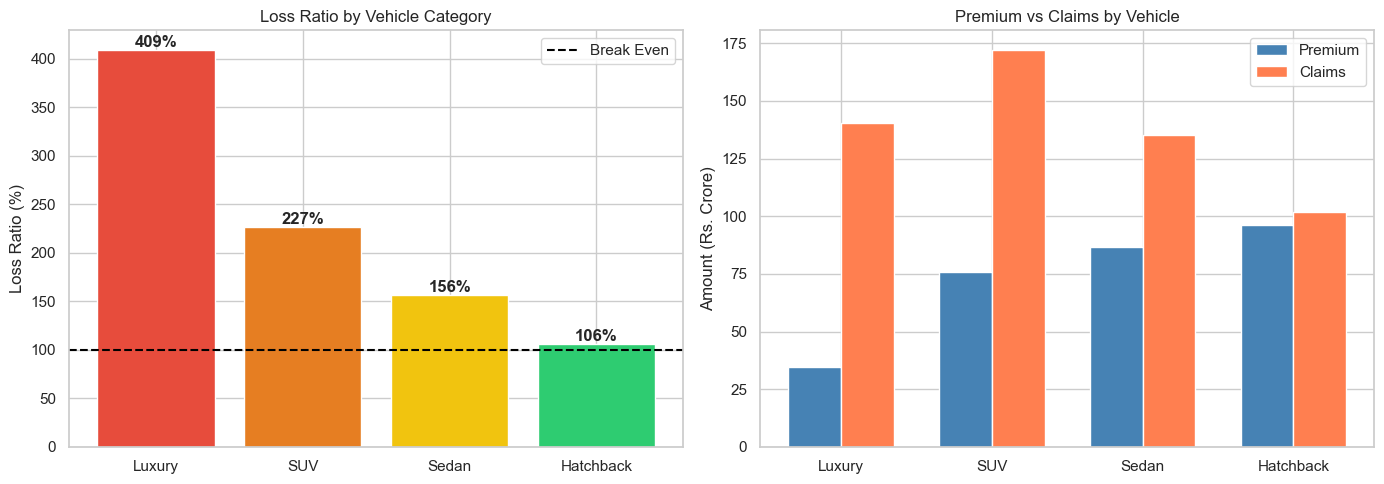

In [15]:
# luxury has least claims but highest loss ratio
# that is a severity problem not frequency — each luxury claim is massive
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71']
bars = axes[0].bar(vehicle_grp['Vehicle_Category'], vehicle_grp['Loss_Ratio'],
                   color=colors, edgecolor='white')
axes[0].axhline(y=100, color='black', linestyle='--', linewidth=1.5, label='Break Even')
axes[0].set_title('Loss Ratio by Vehicle Category')
axes[0].set_ylabel('Loss Ratio (%)')
axes[0].legend()
for bar, val in zip(bars, vehicle_grp['Loss_Ratio']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                f'{val:.0f}%', ha='center', fontweight='bold')

x = np.arange(len(vehicle_grp))
w = 0.35
axes[1].bar(x - w/2, vehicle_grp['Total_Premium']/1e7, w, label='Premium', color='steelblue')
axes[1].bar(x + w/2, vehicle_grp['Total_Claims']/1e7, w, label='Claims', color='coral')
axes[1].set_title('Premium vs Claims by Vehicle')
axes[1].set_xticks(x)
axes[1].set_xticklabels(vehicle_grp['Vehicle_Category'])
axes[1].set_ylabel('Amount (Rs. Crore)')
axes[1].legend()

plt.tight_layout()
plt.show()


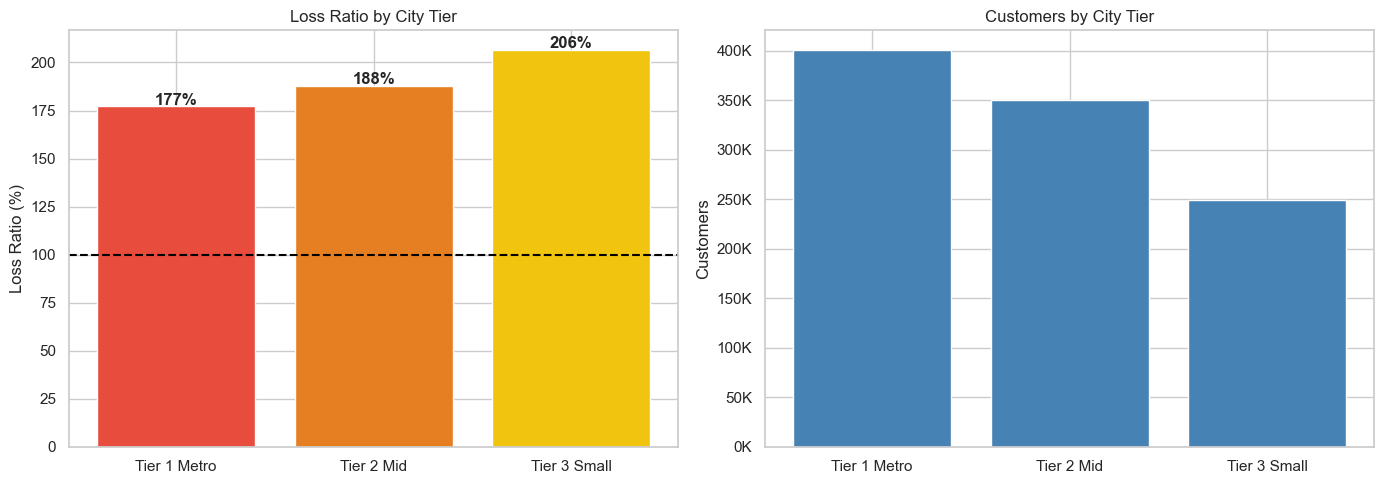

In [16]:
# by city tier
city_grp = merged.groupby('City_Tier').agg(
    Total_Premium = ('Premium', 'sum'),
    Total_Claims  = ('Claim_Amount', 'sum'),
    Customers     = ('Customer_ID_x', 'count')
).reset_index().fillna(0)

city_grp['Loss_Ratio'] = (city_grp['Total_Claims'] / city_grp['Total_Premium'] * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

clabels = ['Tier 1 Metro', 'Tier 2 Mid', 'Tier 3 Small']
bars = axes[0].bar(clabels, city_grp['Loss_Ratio'],
                   color=['#e74c3c', '#e67e22', '#f1c40f'], edgecolor='white')
axes[0].axhline(y=100, color='black', linestyle='--', linewidth=1.5)
axes[0].set_title('Loss Ratio by City Tier')
axes[0].set_ylabel('Loss Ratio (%)')
for bar, val in zip(bars, city_grp['Loss_Ratio']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val:.0f}%', ha='center', fontweight='bold')

axes[1].bar(clabels, city_grp['Customers'], color='steelblue', edgecolor='white')
axes[1].set_title('Customers by City Tier')
axes[1].set_ylabel('Customers')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

plt.tight_layout()
plt.show()


## Monthly Claim Trend

Claims were steady through 2025 because sales were evenly spread across the year.
The spike in Jan-Feb 2026 is from 4-year tenure customers filing second claims.
That is long tail liability — collected premium in 2024 but claims came in 2026.


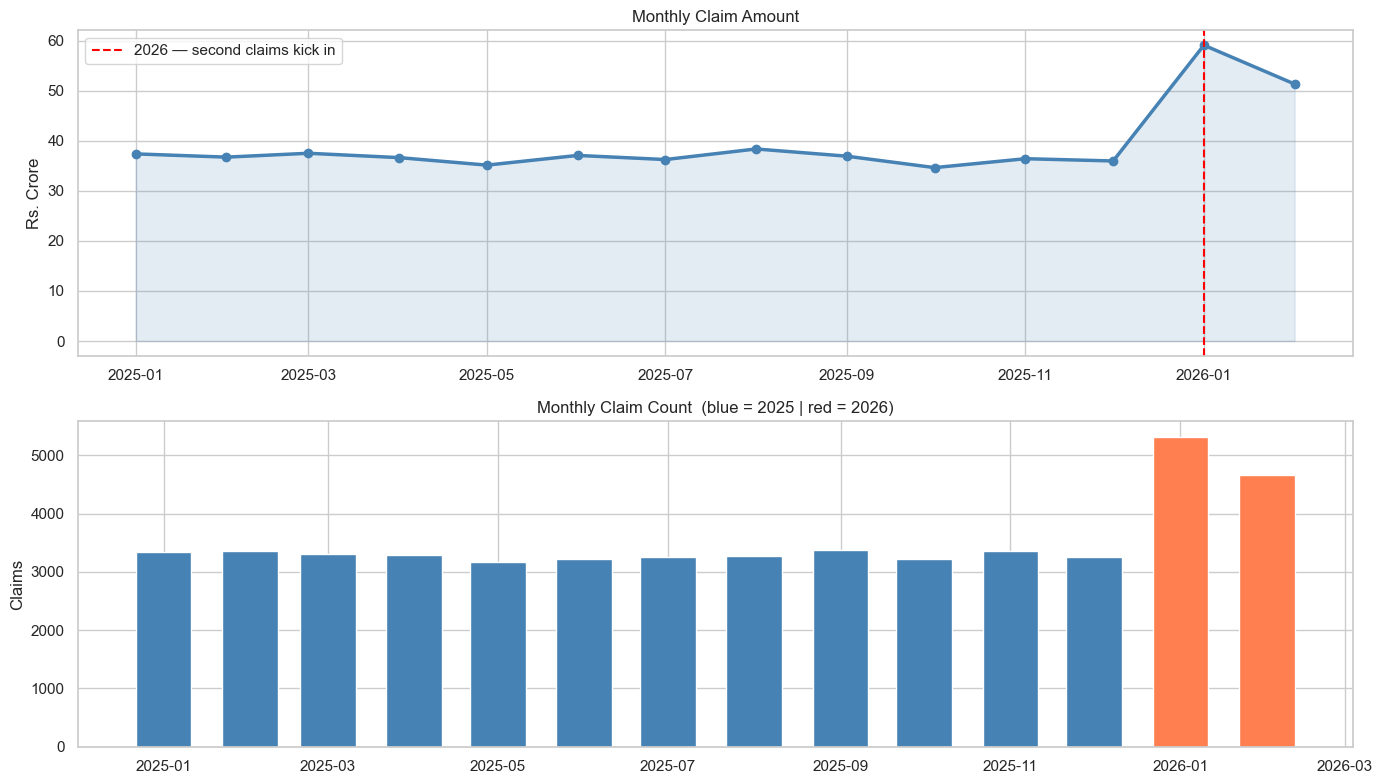

In [17]:
claims['Period'] = pd.to_datetime(
    claims['Claim_Date'].dt.to_period('M').astype(str)
)

monthly = claims.groupby('Period').agg(
    Total_Claims = ('Claim_Amount', 'sum'),
    Claim_Count  = ('Claim_ID', 'count')
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(monthly['Period'], monthly['Total_Claims']/1e7,
             marker='o', linewidth=2.5, color='steelblue', markersize=6)
axes[0].fill_between(monthly['Period'], monthly['Total_Claims']/1e7, alpha=0.15, color='steelblue')
axes[0].axvline(x=pd.Timestamp('2026-01-01'), color='red', linestyle='--',
                linewidth=1.5, label='2026 — second claims kick in')
axes[0].set_title('Monthly Claim Amount')
axes[0].set_ylabel('Rs. Crore')
axes[0].legend()

axes[1].bar(monthly['Period'], monthly['Claim_Count'],
            color=['coral' if p.year == 2026 else 'steelblue' for p in monthly['Period']],
            edgecolor='white', width=20)
axes[1].set_title('Monthly Claim Count  (blue = 2025 | red = 2026)')
axes[1].set_ylabel('Claims')

plt.tight_layout()
plt.show()


In [18]:
avg_2025 = monthly[monthly['Period'].dt.year == 2025]['Total_Claims'].mean()
avg_2026 = monthly[monthly['Period'].dt.year == 2026]['Total_Claims'].mean()
print(f"Avg monthly claims 2025 : Rs. {avg_2025:,.0f}")
print(f"Avg monthly claims 2026 : Rs. {avg_2026:,.0f}")
print(f"Increase                : {(avg_2026 - avg_2025) / avg_2025 * 100:.1f}%")


Avg monthly claims 2025 : Rs. 366,037,671
Avg monthly claims 2026 : Rs. 552,412,545
Increase                : 50.9%


## Fraud Analysis

Fraud is only 2% of claims by count but 15% by amount.
That gap is because fraud claims are set to 90% of vehicle value — so one luxury fraud = Rs. 22.5L.
Checking which segments are most exposed.


In [19]:
fraud = claims[claims['Is_Fraud_Flag'] == 1]

print(f"Fraud claims     : {len(fraud):,}  ({len(fraud)/len(claims)*100:.2f}% of total)")
print(f"Fraud amount     : Rs. {fraud['Claim_Amount'].sum():,.0f}  ({fraud['Claim_Amount'].sum()/claims['Claim_Amount'].sum()*100:.2f}% of total)")


Fraud claims     : 967  (1.96% of total)
Fraud amount     : Rs. 826,560,000  (15.04% of total)


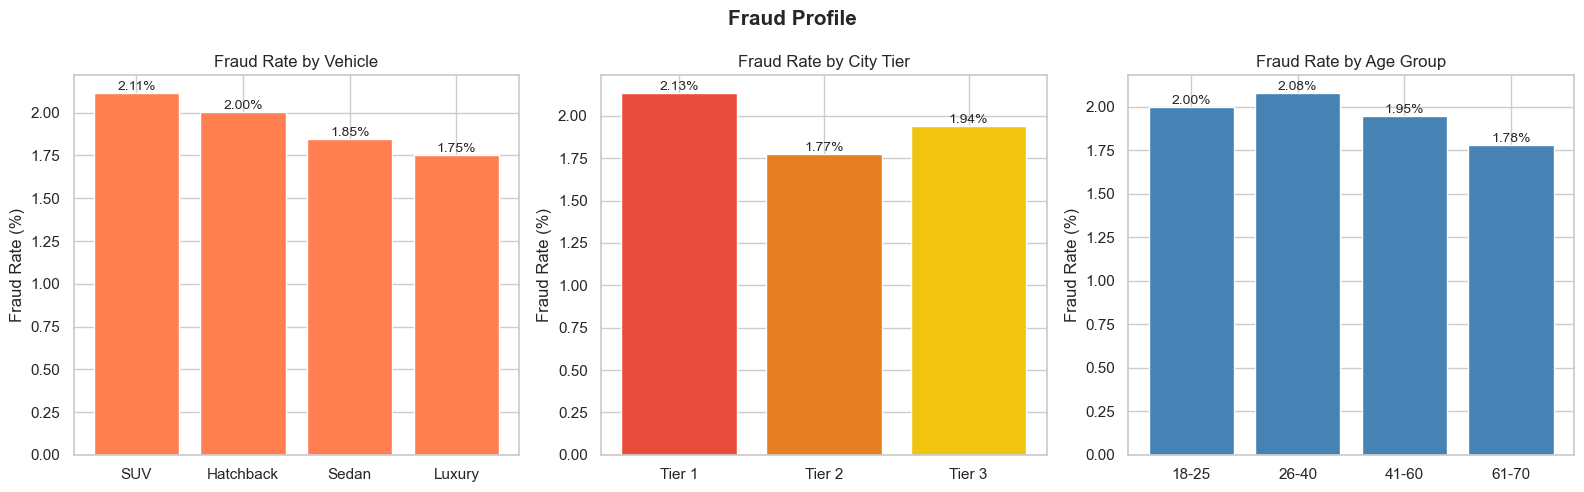

In [20]:
merged_inner = policy.merge(claims, on='Vehicle_ID', how='inner')

# fraud rate by vehicle category
fv = merged_inner.groupby('Vehicle_Category').agg(
    Total  = ('Claim_ID', 'count'),
    Frauds = ('Is_Fraud_Flag', 'sum')
).reset_index()
fv['Fraud_Rate'] = fv['Frauds'] / fv['Total'] * 100
fv = fv.sort_values('Fraud_Rate', ascending=False)

# fraud rate by city tier
fc = merged_inner.groupby('City_Tier').agg(
    Total  = ('Claim_ID', 'count'),
    Frauds = ('Is_Fraud_Flag', 'sum')
).reset_index()
fc['Fraud_Rate'] = fc['Frauds'] / fc['Total'] * 100

# fraud rate by age group
merged_inner['Age_Group'] = pd.cut(
    merged_inner['Customer_Age'],
    bins=[17, 25, 40, 60, 70],
    labels=['18-25', '26-40', '41-60', '61-70']
)
fa = merged_inner.groupby('Age_Group', observed=True).agg(
    Total  = ('Claim_ID', 'count'),
    Frauds = ('Is_Fraud_Flag', 'sum')
).reset_index()
fa['Fraud_Rate'] = fa['Frauds'] / fa['Total'] * 100

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].bar(fv['Vehicle_Category'], fv['Fraud_Rate'], color='coral', edgecolor='white')
axes[0].set_title('Fraud Rate by Vehicle')
axes[0].set_ylabel('Fraud Rate (%)')
for i, val in enumerate(fv['Fraud_Rate']):
    axes[0].text(i, val + 0.02, f'{val:.2f}%', ha='center', fontsize=10)

axes[1].bar(['Tier 1', 'Tier 2', 'Tier 3'], fc['Fraud_Rate'],
            color=['#e74c3c', '#e67e22', '#f1c40f'], edgecolor='white')
axes[1].set_title('Fraud Rate by City Tier')
axes[1].set_ylabel('Fraud Rate (%)')
for i, val in enumerate(fc['Fraud_Rate']):
    axes[1].text(i, val + 0.02, f'{val:.2f}%', ha='center', fontsize=10)

axes[2].bar(fa['Age_Group'].astype(str), fa['Fraud_Rate'], color='steelblue', edgecolor='white')
axes[2].set_title('Fraud Rate by Age Group')
axes[2].set_ylabel('Fraud Rate (%)')
for i, val in enumerate(fa['Fraud_Rate']):
    axes[2].text(i, val + 0.02, f'{val:.2f}%', ha='center', fontsize=10)

plt.suptitle('Fraud Profile', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


## Claim Frequency by Age Group

This checks what % of customers in each age group actually filed a claim.
Different from claim count — accounts for group size.


In [21]:
policy['Age_Group'] = pd.cut(
    policy['Customer_Age'],
    bins=[17, 25, 40, 60, 70],
    labels=['18-25', '26-40', '41-60', '61-70']
)

total_by_age = policy.groupby('Age_Group', observed=True)['Customer_ID'].count().reset_index()
total_by_age.columns = ['Age_Group', 'Total']

claimants = policy[policy['Vehicle_ID'].isin(claims['Vehicle_ID'])]
claimed_by_age = claimants.groupby('Age_Group', observed=True)['Customer_ID'].nunique().reset_index()
claimed_by_age.columns = ['Age_Group', 'Claimed']

age_freq = total_by_age.merge(claimed_by_age, on='Age_Group')
age_freq['Claim_Rate'] = age_freq['Claimed'] / age_freq['Total'] * 100

age_freq


,Age_Group,Total,Claimed,Claim_Rate
0,18-25,150735,7453,4.944439
1,26-40,283237,13913,4.912141
2,41-60,377214,18452,4.891653
3,61-70,188814,9151,4.846569


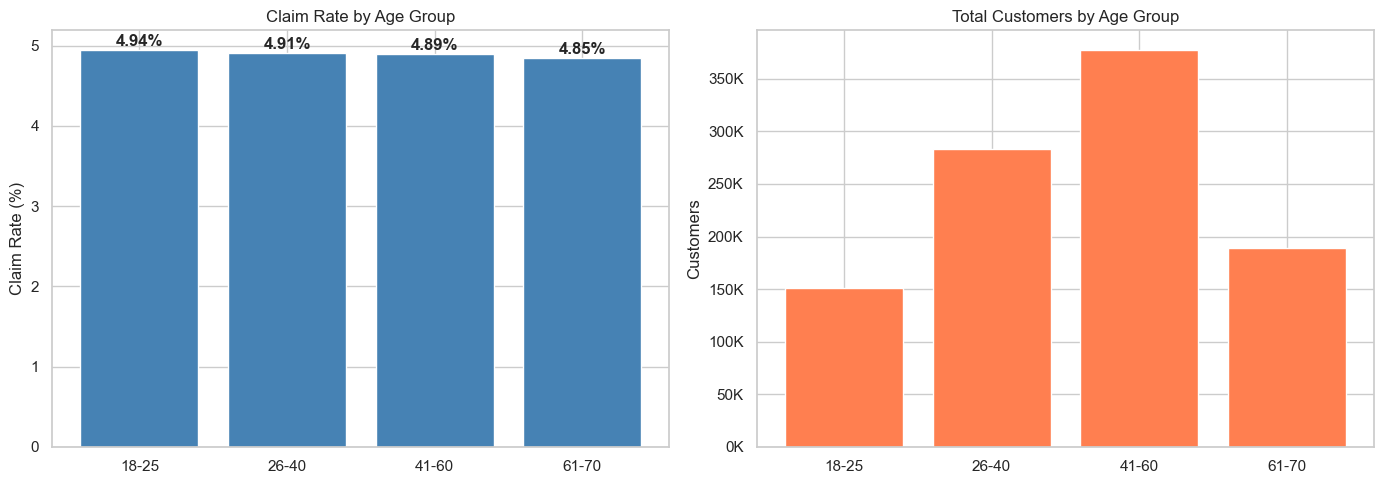

Claim rates are uniform across age groups — expected since age was not
a factor in claim selection during simulation.
In real insurance data a U-shaped pattern would be observed.


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(age_freq['Age_Group'].astype(str), age_freq['Claim_Rate'],
            color='steelblue', edgecolor='white')
axes[0].set_title('Claim Rate by Age Group')
axes[0].set_ylabel('Claim Rate (%)')
for i, val in enumerate(age_freq['Claim_Rate']):
    axes[0].text(i, val + 0.05, f'{val:.2f}%', ha='center', fontweight='bold')

axes[1].bar(age_freq['Age_Group'].astype(str), age_freq['Total'],
            color='coral', edgecolor='white')
axes[1].set_title('Total Customers by Age Group')
axes[1].set_ylabel('Customers')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

plt.tight_layout()
plt.show()

# all groups are around 4.9% — age wasnt a factor in simulation
# in real data younger and older drivers would show higher rates
print("Claim rates are uniform across age groups — expected since age was not")
print("a factor in claim selection during simulation.")
print("In real insurance data a U-shaped pattern would be observed.")


## Earned Premium and Future Liability

Earned premium = how much of collected premium has actually been earned based on coverage days elapsed.
Unearned premium = still owed as future coverage, cannot be counted as profit yet.
Future liability = potential claim exposure from customers who have not claimed yet.


In [23]:
cutoff = pd.Timestamp('2026-02-28')

active = policy[policy['Policy_Start_Date'] < cutoff].copy()
active['Daily_Premium'] = active['Premium'] / (active['Policy_Tenure'] * 365)
active['Days_Elapsed'] = (cutoff - active['Policy_Start_Date']).dt.days.clip(
    upper=active['Policy_Tenure'] * 365
)
active['Earned'] = active['Daily_Premium'] * active['Days_Elapsed']

earned   = active['Earned'].sum()
unearned = policy['Premium'].sum() - earned

print(f"Earned Premium   : Rs. {earned:,.0f}  ({earned/policy['Premium'].sum()*100:.1f}%)")
print(f"Unearned Premium : Rs. {unearned:,.0f}  ({unearned/policy['Premium'].sum()*100:.1f}%)")


Earned Premium   : Rs. 804,715,691  (27.5%)
Unearned Premium : Rs. 2,124,590,771  (72.5%)


In [24]:
unclaimed_v   = policy[~policy['Vehicle_ID'].isin(claims['Vehicle_ID'])]
future_liab   = len(unclaimed_v) * claims['Claim_Amount'].mean()

print(f"Unclaimed vehicles    : {len(unclaimed_v):,}")
print(f"Avg claim amount      : Rs. {claims['Claim_Amount'].mean():,.0f}")
print(f"Future claim liability: Rs. {future_liab:,.0f}")
print(f"                        Rs. {future_liab/1e9:.2f} Billion")


Unclaimed vehicles    : 951,031
Avg claim amount      : Rs. 111,355
Future claim liability: Rs. 105,902,343,219
                        Rs. 105.90 Billion


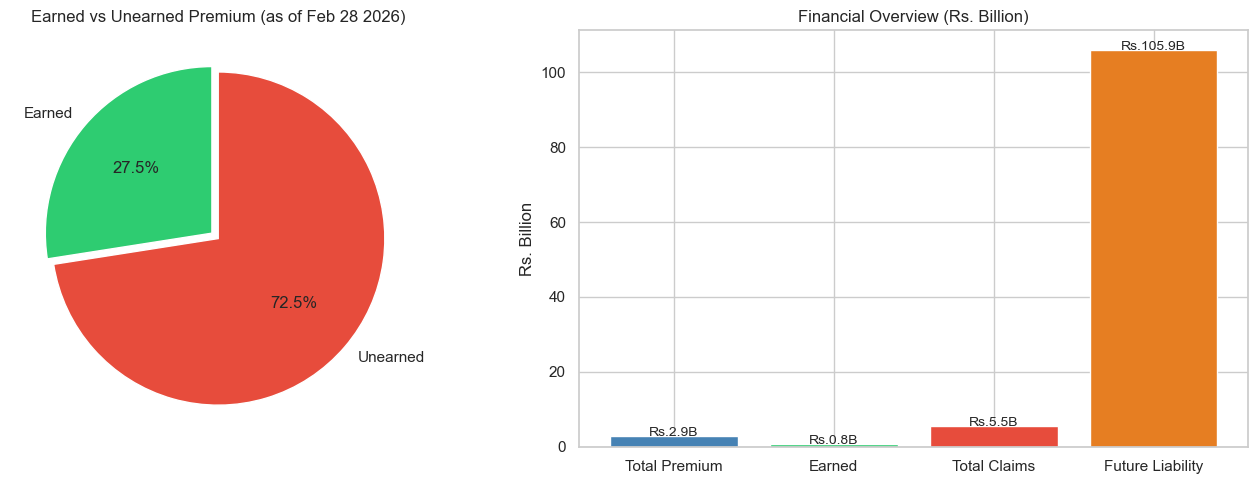

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].pie(
    [earned, unearned],
    labels=['Earned', 'Unearned'],
    colors=['#2ecc71', '#e74c3c'],
    autopct='%1.1f%%',
    startangle=90,
    explode=(0.05, 0)
)
axes[0].set_title('Earned vs Unearned Premium (as of Feb 28 2026)')

categories = ['Total Premium', 'Earned', 'Total Claims', 'Future Liability']
values = [
    policy['Premium'].sum()/1e9,
    earned/1e9,
    claims['Claim_Amount'].sum()/1e9,
    future_liab/1e9
]
bars = axes[1].bar(categories, values,
                   color=['steelblue', '#2ecc71', '#e74c3c', '#e67e22'],
                   edgecolor='white')
axes[1].set_title('Financial Overview (Rs. Billion)')
axes[1].set_ylabel('Rs. Billion')
for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'Rs.{val:.1f}B', ha='center', fontsize=10)

plt.tight_layout()
plt.show()


## Key Findings

| # | Finding | Recommendation |
|---|---------|----------------|
| 1 | Portfolio loss ratio is 187% — paying out more than collecting | Reprice across all segments urgently |
| 2 | Luxury loss ratio is 408% with fewest claims | Severity problem — premiums need 4-5x increase |
| 3 | 4-year tenure has 350% loss ratio and hidden future liability | Reprice or stop selling 4-year policies |
| 4 | Fraud is 1.96% of claims but 15% of total payout | Focus fraud investigation on high value claims |
| 5 | Tier 1 metro cities have highest fraud rate at 2.13% | Stricter verification in metro cities |
| 6 | 26-40 age group has highest fraud rate | Flag this segment for additional review |
| 7 | 2026 claims spiked 60% from 4-year second claims | Reserve for long tail liability properly |
| 8 | Rs. 1060 Crore potential future liability from unclaimed policies | Maintain adequate claims reserve |
